# Raw Reaction Model Bakeoff Control Panel

Use this notebook to run the full experiment from one place: freeze tasks, run candidate generation, run the strong-model gold audit, score results, and inspect visuals.

Live model calls are behind explicit switches in the setup cell. Start with a smoke run before spending on the full configuration.

## 1. Setup

In [1]:
from pathlib import Path
from pprint import pprint
import json
import os
import sys

cwd = Path.cwd().resolve()
REPO_ROOT = cwd
while REPO_ROOT.name != "chemy" and REPO_ROOT.parent != REPO_ROOT:
    REPO_ROOT = REPO_ROOT.parent
assert REPO_ROOT.name == "chemy", (
    f"Could not find repo root named 'chemy' — walked up to {REPO_ROOT}. "
    "Launch Jupyter from inside the chemy repository."
)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from experiments.model_quality.helpers import load_config, read_jsonl
from experiments.model_quality.sample import build_tasks
from experiments.model_quality.run_generation import run_generation
from experiments.model_quality.run_gold_audit import run_gold_audit
from experiments.model_quality.score import build_summary

CONFIG_PATH = REPO_ROOT / "experiments" / "model_quality" / "config.yaml"

# Safety switches — keep False until you intentionally want to call live models.
RUN_FREEZE_TASKS = True
RUN_GENERATION = True
RUN_GOLD_AUDIT = True
RUN_SCORE = True

# Smoke mode overrides the loaded config in-memory only. It does not edit config.yaml.
SMOKE_MODE = True
SMOKE_MODELS = ["openai/gpt-oss-120b"]
SMOKE_PRESETS = ["wiki_crc_rp"]
SMOKE_COMPLEXITY_BANDS = ["simple"]
SMOKE_GENERATION_RUN_LIMIT = 2
SMOKE_MAX_WORKERS = 2

DATA_DIR = REPO_ROOT / "experiments" / "model_quality" / ("data_smoke" if SMOKE_MODE else "data")
SUMMARY_PATH = DATA_DIR / "summary.json"

config = load_config(CONFIG_PATH)
if SMOKE_MODE:
    config = {
        **config,
        "tasks_per_band": 1,
        "gold_rounds": 1,
        "candidate_models": SMOKE_MODELS,
        "bakeoff_presets": SMOKE_PRESETS,
        "complexity_bands": SMOKE_COMPLEXITY_BANDS,
        "generation_self_review": False,
        "max_workers": SMOKE_MAX_WORKERS,
    }
GENERATION_RUN_LIMIT = SMOKE_GENERATION_RUN_LIMIT if SMOKE_MODE else None

print(f"Repo root: {REPO_ROOT}")
print(f"Config:    {CONFIG_PATH}")
print(f"Data dir:  {DATA_DIR}")
print(f"API key present: {bool(os.getenv('OPENROUTER_API_KEY'))}")
print(f"Live switches: freeze={RUN_FREEZE_TASKS}, generation={RUN_GENERATION}, gold={RUN_GOLD_AUDIT}, score={RUN_SCORE}")
print(f"Generation run limit: {GENERATION_RUN_LIMIT}")
print(f"Max workers: {config['max_workers']}")
pprint(config)

Repo root: /home/canary/Documents/Code/chemy
Config:    /home/canary/Documents/Code/chemy/experiments/model_quality/config.yaml
Data dir:  /home/canary/Documents/Code/chemy/experiments/model_quality/data_smoke
API key present: True
Live switches: freeze=True, generation=True, gold=True, score=True
Generation run limit: 2
Max workers: 2
{'acceptance_threshold': 0.4,
 'bakeoff_presets': ['wiki_crc_rp'],
 'batch_size': 5,
 'candidate_models': ['openai/gpt-oss-120b'],
 'chemy_data_dir': 'data',
 'complexity_bands': ['simple'],
 'generation_self_review': False,
 'gold_rounds': 1,
 'max_workers': 2,
 'seed': 1729,
 'strong_model': 'google/gemini-2.5-pro',
 'tasks_per_band': 1}


## 2. Freeze Tasks

In [2]:
if RUN_FREEZE_TASKS:
    tasks_path, task_manifest = build_tasks(config, data_dir=DATA_DIR, root=REPO_ROOT)
    print(f"Wrote {task_manifest['task_n']} tasks to {tasks_path}")
else:
    task_manifest_path = DATA_DIR / "manifests" / "task_manifest.json"
    task_manifest = json.loads(task_manifest_path.read_text()) if task_manifest_path.exists() else None
    print("Task freezing skipped.")

tasks = read_jsonl(DATA_DIR / "tasks.jsonl")
print(f"Frozen task rows: {len(tasks)}")
tasks[:3]

Wrote 1 tasks to /home/canary/Documents/Code/chemy/experiments/model_quality/data_smoke/tasks.jsonl
Frozen task rows: 1


[{'task_id': 'task:9e2807a7382066c261b1f7f55ddef22ddd5a09a4',
  'cid': 14827,
  'compound_name': 'Lead monoxide',
  'preset': 'wiki_crc_rp',
  'position': 'any',
  'scope': 'documented_less_common',
  'prompt': 'Provide a list of documented chemical reactions involving Lead monoxide, where it appears as a reagent or product. Include not only the most common reactions, but also less common or unusual ones, as long as you are absolutely sure they are real and correct. Return one JSON object per line (JSONL). Each JSON object has these fields:\n- "reagents": list of {"name": "<clean chemical name>", "phase": "<g|l|s|aq>"}\n- "products": list of {"name": "<clean chemical name>", "phase": "<g|l|s|aq>"}\n- Optional "solvent": primary solvent name or null\n- Optional "catalyst": catalyst name or null\n- Optional per-compound "note": short qualifier; omit it when not needed\n\nRules:\n- Use full chemical names, not formulas.\n- The name field must contain ONLY the chemical name.\n- Put qualifi

## 3. Run Candidate Generation

In [3]:
if RUN_GENERATION:
    generation_manifest = run_generation(
        config,
        data_dir=DATA_DIR,
        root=REPO_ROOT,
        models=config["candidate_models"],
        run_limit=GENERATION_RUN_LIMIT,
        max_workers=config["max_workers"],
    )
    pprint(generation_manifest)
else:
    print("Generation skipped.")

generations = read_jsonl(DATA_DIR / "generations.jsonl")
candidates = read_jsonl(DATA_DIR / "candidates.jsonl")
print(f"Generation rows: {len(generations)}")
print(f"Candidate rows:  {len(candidates)}")
candidates[:3]

[11:16:17] INFO     Generating model-quality reactions: submitted 1 entries                            ]8;id=556979;file:///home/canary/Documents/Code/chemy/scripts/infra/logger.py\logger.py]8;;\:]8;id=721299;file:///home/canary/Documents/Code/chemy/scripts/infra/logger.py#45\45]8;;\

/home/canary/miniconda3/envs/chems-env/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/canary/miniconda3/envs/chems-env/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

{'candidate_n': 5,
 'generation_self_review': False,
 'max_workers': 2,
 'models': ['openai/gpt-oss-120b'],
 'ran': 1,
 'run_limit': 2,
 'skipped': 0,
 'task_n': 1}
Generation rows: 1
Candidate rows:  5


[{'candidate_id': 'candidate:87fd062e39e39a7324f77bfcb678e8b7d64dc6f6',
  'output_id': 'reaction:cf3e139217274ac8f8410823d32db91303094f77',
  'task_id': 'task:9e2807a7382066c261b1f7f55ddef22ddd5a09a4',
  'model': 'openai/gpt-oss-120b',
  'reaction_index': 0,
  'reaction': {'reagents': [{'name': 'lead', 'phase': 's'},
    {'name': 'oxygen', 'phase': 'g'}],
   'products': [{'name': 'lead(II) oxide', 'phase': 's', 'note': 'heated'}],
   'solvent': None,
   'catalyst': None},
  'schema_valid': True,
  'parsed': True,
  'rid': 'PnRO09ylchyKIyx4D7nk+Q==',
  'cid': 14827,
  'unmapped_names': [],
  'target_compound_present': True,
  'target_position_correct': True,
  'balance_success': True,
  'duplicate_key': 'PnRO09ylchyKIyx4D7nk+Q==',
  'generation_id': 'generation:47af2ec80a572a611ab82192c377d337d8cba9d6',
  'preset': 'wiki_crc_rp',
  'complexity_band': 'simple',
  'compound_name': 'Lead monoxide',
  'position': 'any'},
 {'candidate_id': 'candidate:dce0208f41ebc16070e2664f1e7106b3cd3054bf'

## 4. Run Gold Audit

In [4]:
if RUN_GOLD_AUDIT:
    pending_candidates = read_jsonl(DATA_DIR / "candidates.jsonl")
    if not pending_candidates:
        print("No candidates found — run the generation cell first.")
    else:
        print(f"Submitting gold audit for up to {len(pending_candidates)} candidates.")
        gold_manifest = run_gold_audit(
            config,
            data_dir=DATA_DIR,
            model=config["strong_model"],
            max_workers=config["max_workers"],
        )
        pprint(gold_manifest)
        if gold_manifest.get("batch_failures", 0):
            print(
                f"\nWARNING: {gold_manifest['batch_failures']} batch(es) failed. "
                "Re-run this cell to retry."
            )
else:
    print("Gold audit skipped.")

gold_audits = read_jsonl(DATA_DIR / "gold_audits.jsonl")
print(f"Gold audit rows: {len(gold_audits)}")
gold_audits[:3]

Submitting gold audit for up to 5 candidates.
Running gold audit batches: submitted 1 entries
{'audited': 5,
 'batch_failures': 0,
 'candidate_count': 5,
 'completed_before': 0,
 'max_workers': 2,
 'model': 'google/gemini-2.5-pro',
 'pending_count': 5,
 'rounds': 1}
Gold audit rows: 5


[{'candidate_id': 'candidate:87fd062e39e39a7324f77bfcb678e8b7d64dc6f6',
  'task_id': 'task:9e2807a7382066c261b1f7f55ddef22ddd5a09a4',
  'model': 'openai/gpt-oss-120b',
  'rid': 'PnRO09ylchyKIyx4D7nk+Q==',
  'output_id': 'reaction:cf3e139217274ac8f8410823d32db91303094f77',
  'gold_model': 'google/gemini-2.5-pro',
  'gold_votes': [{'index': 1, 'valid': True}],
  'gold_rounds': 1,
  'gold_positives': 1,
  'gold_confidence': 1.0},
 {'candidate_id': 'candidate:dce0208f41ebc16070e2664f1e7106b3cd3054bf',
  'task_id': 'task:9e2807a7382066c261b1f7f55ddef22ddd5a09a4',
  'model': 'openai/gpt-oss-120b',
  'rid': 'q0kLdqS3v87jK0vkUiaw3Q==',
  'output_id': 'reaction:f8f8ff397dfb7065a778b01958992c8b3ca0d4a7',
  'gold_model': 'google/gemini-2.5-pro',
  'gold_votes': [{'index': 2, 'valid': True}],
  'gold_rounds': 1,
  'gold_positives': 1,
  'gold_confidence': 1.0},
 {'candidate_id': 'candidate:96f895a2bb40c7f144fc3ff9260e95e418ee48ae',
  'task_id': 'task:9e2807a7382066c261b1f7f55ddef22ddd5a09a4',
  'm

## 5. Score

In [5]:
summary = build_summary(config, data_dir=DATA_DIR)
if RUN_SCORE:
    SUMMARY_PATH.parent.mkdir(parents=True, exist_ok=True)
    SUMMARY_PATH.write_text(json.dumps(summary, indent=2) + "\n")
    print(f"Wrote {SUMMARY_PATH}")

summary["inputs"], summary["models"]

Wrote /home/canary/Documents/Code/chemy/experiments/model_quality/data_smoke/summary.json


({'generations': 1, 'candidates': 5, 'gold_audits': 5},
 {'openai/gpt-oss-120b': {'generation_runs': 1,
   'candidate_n': 5,
   'schema_success_rate': 0.5,
   'parsed_rate': 1.0,
   'target_compound_rate': 1.0,
   'target_position_rate': 1.0,
   'balance_success_rate': 1.0,
   'unique_rid_n': 5,
   'unique_output_id_n': 5,
   'duplicate_rid_rate': 0.0,
   'gold_audited_n': 5,
   'gold_precision': 1.0,
   'gold_accepted_n': 5,
   'gold_accepted_unique_rid_n': 5,
   'input_tokens': 377,
   'completion_tokens': 2128,
   'accepted_unique_rids_per_1k_tokens': 1.996007984031936}})

## 6. Visuals

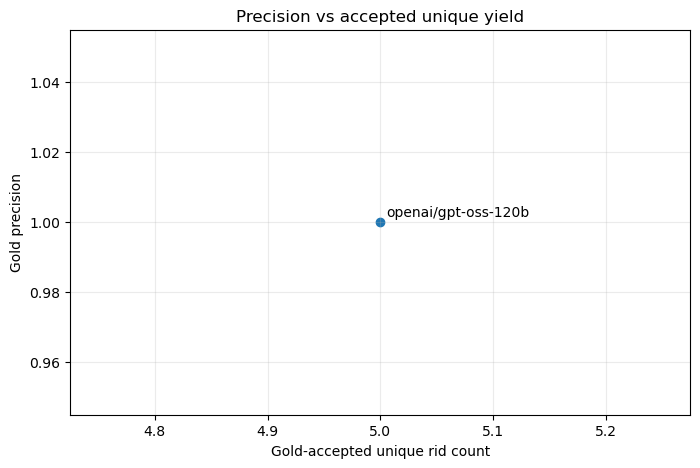

In [6]:
import matplotlib.pyplot as plt

models = list(summary["models"])
if not models:
    print("No scored models yet. Run generation and gold audit first.")
else:
    precision = [summary["models"][m]["gold_precision"] for m in models]
    yield_ = [summary["models"][m]["gold_accepted_unique_rid_n"] for m in models]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(yield_, precision)
    for m, x, y in zip(models, yield_, precision):
        ax.annotate(m, (x, y), xytext=(4, 4), textcoords="offset points")
    ax.set_xlabel("Gold-accepted unique rid count")
    ax.set_ylabel("Gold precision")
    ax.set_title("Precision vs accepted unique yield")
    ax.grid(True, alpha=0.25)

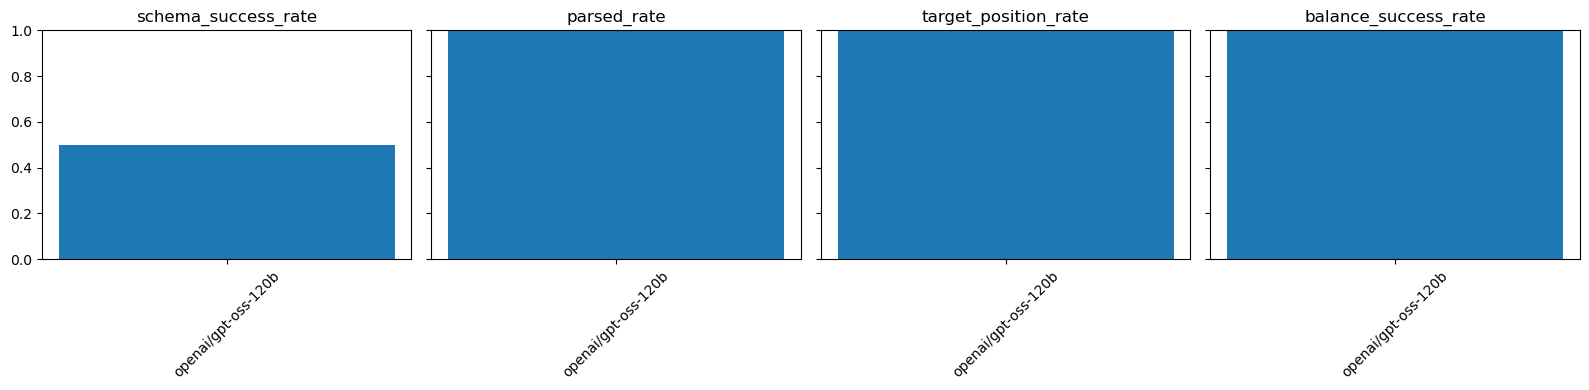

In [7]:
metrics = ["schema_success_rate", "parsed_rate", "target_position_rate", "balance_success_rate"]
if models:
    fig, axes = plt.subplots(1, len(metrics), figsize=(4 * len(metrics), 4), sharey=True)
    for ax, metric in zip(axes, metrics):
        ax.bar(models, [summary["models"][m][metric] for m in models])
        ax.set_title(metric)
        ax.tick_params(axis="x", rotation=45)
        ax.set_ylim(0, 1)
    fig.tight_layout()

In [8]:
summary["bands"]

{'wiki_crc_rp:simple': {'openai/gpt-oss-120b': {'candidate_n': 5,
   'parsed_rate': 1.0,
   'target_position_rate': 1.0,
   'balance_success_rate': 1.0}}}